# Speech2Latex Exploratory Data Analysis

In [1]:
from datasets import load_dataset
import pandas as pd

## Loading the dataset and looking at splits and features

In [2]:
speech2latex = load_dataset("marsianin500/Speech2Latex")
speech2latex

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/124 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/120 [00:00<?, ?it/s]

DatasetDict({
    sentences_train: Dataset({
        features: ['spk', 'language', 'sentence_id', 'is_tts', 'pronunciation', 'whisper_text', 'sentence', 'audio_path', 'formula_info', 'count_formula_symbols', 'count_formula_symbols_strates', '__index_level_0__', 'sentence_normalized'],
        num_rows: 89013
    })
    sentences_test: Dataset({
        features: ['spk', 'language', 'sentence_id', 'is_tts', 'pronunciation', 'whisper_text', 'sentence', 'audio_path', 'formula_info', 'count_formula_symbols', 'count_formula_symbols_strates', '__index_level_0__', 'sentence_normalized'],
        num_rows: 2850
    })
    equations_train: Dataset({
        features: ['spk', 'language', 'sentence_id', 'is_tts', 'pronunciation', 'whisper_text', 'sentence', 'audio_path', 'formula_info', 'count_formula_symbols', 'count_formula_symbols_strates', '__index_level_0__', 'sentence_normalized'],
        num_rows: 142846
    })
    equations_test: Dataset({
        features: ['spk', 'language', 'sentence_

## Looking at a singular sample

In [3]:
train = speech2latex["sentences_train"]
sample = next(iter(train))
sample

{'spk': 'D_voice',
 'language': 'eng',
 'sentence_id': 0,
 'is_tts': 1,
 'pronunciation': 'We minimize the above effective-Hamiltonian with respect to the parameters <formula_start>r 1, r 2, r 3, r 4<formula_end>, and <formula_start>theta 12, theta 13, theta 14, theta 23, theta 24, theta 34<formula_end> respectively and obtain the corresponding ground state energy <formula_start>epsilon infinity equals negative 0.875837<formula_end>.',
 'whisper_text': 'We minimize the above-effective Hamiltonian with respect to the parameters R1, R2, R3, R4, and theta 12, theta 13, theta 14, theta 14, theta 23, theta 23, theta 24, theta 34, and 7, infinity. Equalist.',
 'sentence': 'We minimize the above effective-Hamiltonian with respect to the parameters $r_1, r_2, r_3, r_4$, and $\\theta_{12}, \\theta_{13}, \\theta_{14}, \\theta_{23},\\theta_{24}, \\theta_{34}$ respectively and obtain the corresponding ground state energy $\\epsilon_\\infty = -0.875837$.',
 'audio_path': <datasets.features._torchco

## Analyzing the audio array (An array containing samples of discrete amplitude measurements at a point of time)

In [4]:
samples = sample["audio_path"].get_all_samples()
audio = samples.data
audio

tensor([[-0.0566, -0.0568, -0.0579,  ...,  0.0000,  0.0000,  0.0000]])

In [5]:
audio.shape

torch.Size([1, 531472])

In [6]:
samples.sample_rate

24000

In [7]:
samples.data.shape[-1] / samples.sample_rate

22.144666666666666

## Analyzing Language

In [8]:
train = speech2latex["sentences_train"]
test = speech2latex["sentences_test"]
len(train)
len(test)

2850

## Converting to Pandas Dataframes

In [9]:
train_light = train.remove_columns(["audio_path"])
df_train = train_light.to_pandas()
df_train.head()

,spk,language,sentence_id,is_tts,pronunciation,whisper_text,sentence,formula_info,count_formula_symbols,count_formula_symbols_strates,__index_level_0__,sentence_normalized
0,D_voice,eng,0,1,We minimize the above effective-Hamiltonian wi...,We minimize the above-effective Hamiltonian wi...,We minimize the above effective-Hamiltonian wi...,"[[75, 95, '$r_1, r_2, r_3, r_4$', 'r_1, r_2, r...",126.0,50+,0,We minimize the above effective-Hamiltonian wi...
1,D_voice,eng,0,1,We minimize the above effective-Hamiltonian wi...,We minimize the above-effective Hamiltonian wi...,We minimize the above effective-Hamiltonian wi...,"[[75, 95, '$r_1, r_2, r_3, r_4$', 'r_1, r_2, r...",126.0,50+,1,We minimize the above effective-Hamiltonian wi...
2,Kin_24000,eng,0,1,We minimize the above effective-Hamiltonian wi...,We minimize the above-effective Hamiltonian wi...,We minimize the above effective-Hamiltonian wi...,"[[75, 95, '$r_1, r_2, r_3, r_4$', 'r_1, r_2, r...",126.0,50+,2,We minimize the above effective-Hamiltonian wi...
3,g300,eng,0,1,We minimize the above effective-Hamiltonian wi...,We minimize the above effective Hamiltonian wi...,We minimize the above effective-Hamiltonian wi...,"[[75, 95, '$r_1, r_2, r_3, r_4$', 'r_1, r_2, r...",126.0,50+,3,We minimize the above effective-Hamiltonian wi...
4,g300,eng,0,1,We minimize the above effective-Hamiltonian wi...,We minimize the above effective Hamiltonian wi...,We minimize the above effective-Hamiltonian wi...,"[[75, 95, '$r_1, r_2, r_3, r_4$', 'r_1, r_2, r...",126.0,50+,4,We minimize the above effective-Hamiltonian wi...


In [10]:
test_light = test.remove_columns(["audio_path"])
df_test = test_light.to_pandas()
df_test.head()

,spk,language,sentence_id,is_tts,pronunciation,whisper_text,sentence,formula_info,count_formula_symbols,count_formula_symbols_strates,__index_level_0__,sentence_normalized
0,810c7f88-d103-4082-9ab5-215052e6176b,eng,37,0,"Given a fixed graph F, a typical problem in ex...","Given a fixed graph f, a typical problem in ex...","Given a fixed graph $F$, a typical problem in ...","[[20, 23, '$F$', 'F'], [124, 127, '$G$', 'G'],...",29.0,20-30,235,"Given a fixed graph $F$, a typical problem in ..."
1,D_voice,eng,37,1,Given a fixed graph <formula_start>F<formula_e...,"Given a fixed graph f, a typical problem in ex...","Given a fixed graph $F$, a typical problem in ...","[[20, 23, '$F$', 'F'], [124, 127, '$G$', 'G'],...",29.0,20-30,236,"Given a fixed graph $F$, a typical problem in ..."
2,D_voice,eng,37,1,Given a fixed graph <formula_start>F<formula_e...,"Given a fixed graph F, a typical problem in ex...","Given a fixed graph $F$, a typical problem in ...","[[20, 23, '$F$', 'F'], [124, 127, '$G$', 'G'],...",29.0,20-30,237,"Given a fixed graph $F$, a typical problem in ..."
3,Kin_24000,eng,37,1,Given a fixed graph <formula_start>F<formula_e...,"Given a fixed graph f, a typical problem in ex...","Given a fixed graph $F$, a typical problem in ...","[[20, 23, '$F$', 'F'], [124, 127, '$G$', 'G'],...",29.0,20-30,238,"Given a fixed graph $F$, a typical problem in ..."
4,Kin_24000,eng,37,1,Given a fixed graph <formula_start>F<formula_e...,"Given a fixed graph f, a typical problem in ex...","Given a fixed graph $F$, a typical problem in ...","[[20, 23, '$F$', 'F'], [124, 127, '$G$', 'G'],...",29.0,20-30,239,"Given a fixed graph $F$, a typical problem in ..."


## Training Dataset Text Exploration

In [11]:
df_train.describe()

,sentence_id,is_tts,count_formula_symbols,__index_level_0__
count,89013.000000,89013.000000,89013.000000,89013.000000
mean,7905.915114,0.730129,25.628582,51785.789256
std,4563.638010,0.443895,24.403053,29825.149501
min,0.000000,0.000000,0.000000,0.000000
25%,3994.000000,0.000000,8.000000,26010.000000
50%,7908.000000,1.000000,20.000000,51872.000000
75%,11815.000000,1.000000,34.000000,77583.000000
max,16420.000000,1.000000,247.000000,102952.000000


In [12]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 89013 entries, 0 to 89012
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   spk                            89013 non-null  str    
 1   language                       89013 non-null  str    
 2   sentence_id                    89013 non-null  int64  
 3   is_tts                         89013 non-null  int64  
 4   pronunciation                  89013 non-null  str    
 5   whisper_text                   89013 non-null  str    
 6   sentence                       89013 non-null  str    
 7   formula_info                   89013 non-null  str    
 8   count_formula_symbols          89013 non-null  float64
 9   count_formula_symbols_strates  89013 non-null  str    
 10  __index_level_0__              89013 non-null  int64  
 11  sentence_normalized            89013 non-null  str    
dtypes: float64(1), int64(3), str(8)
memory usage: 65.5 MB


In [13]:
df_train.duplicated().sum()

np.int64(0)

In [14]:
df_train.isnull().sum()

spk                              0
language                         0
sentence_id                      0
is_tts                           0
pronunciation                    0
whisper_text                     0
sentence                         0
formula_info                     0
count_formula_symbols            0
count_formula_symbols_strates    0
__index_level_0__                0
sentence_normalized              0
dtype: int64

In [15]:
df_train["language"].value_counts()

language
eng    89013
Name: count, dtype: int64

In [16]:
df_train["is_tts"].value_counts()

is_tts
1    64991
0    24022
Name: count, dtype: int64

In [17]:
df_train.value_counts(subset=["spk", "is_tts"])

spk                                   is_tts
g300                                  1         21737
D_voice                               1         21637
Kin_24000                             1         21617
b316c983-fcbc-435e-bb58-6a73b3358923  0          9319
70610f1b-ab5d-414d-9bfe-7ccaf36b2408  0          3978
a69e7ff9-0629-45c9-a8d9-633814503533  0          2350
9875433f-1c5a-41ce-bdee-d533eeea3d44  0          1434
810c7f88-d103-4082-9ab5-215052e6176b  0          1390
61b701a7-8eac-4920-89ac-f914a74892f7  0          1246
6f955635-b2d3-4da6-bdc1-1aa6655021ff  0          1127
fa1067fc-8b55-4571-95ee-eec0b99ca278  0          1116
6aba0f6b-abcf-4045-b529-f3f905474093  0           583
9849dba0-57ba-4010-8adc-f88bcff9e585  0           442
308e3ec9-b238-4d6c-ad66-c05896a00a15  0           393
1d0b98eb-b5f9-488f-97f4-bf6423f1560b  0           174
9ed0c969-c4b8-45d2-b1bf-e79eef6ca3a9  0           141
f5a5686a-35e6-40a0-925c-065b5c9ebde8  0           133
6f001cce-fead-4f85-9fcd-9c77427b5197 

count    89013.000000
mean        19.331311
std          8.601134
min          1.000000
25%         13.000000
50%         18.000000
75%         25.000000
max         61.000000
Name: sentence, dtype: float64


<Axes: >

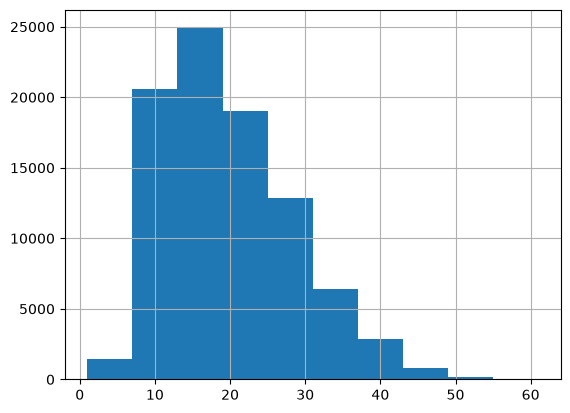

In [18]:
lens = df_train["sentence"].str.split().apply(lambda x: len(x))
print(lens.describe())
lens.hist()

In [19]:
df_train["sentence"].str.lower().str.split().explode().value_counts().head(50)

sentence
the         127051
of           58304
is           42047
and          39842
in           36161
a            34799
to           34045
we           26536
that         24456
for          24262
with         14666
by           12606
be           12601
this         12427
are          11944
as           11940
on            9952
it            7708
from          7481
an            7440
if            7347
=             7181
can           7052
at            6988
which         5902
then          5768
not           5215
all           5092
have          4902
let           4838
will          3961
has           3734
set           3551
each          3485
one           3453
there         3384
also          3365
\in           3335
only          3307
since         3193
when          3132
our           3040
two           3013
equation      3012
where         2975
such          2902
any           2827
function      2811
case          2665
these         2646
Name: count, dtype: int64

In [20]:
print(df_train["sentence_id"].nunique())
df_train["sentence_id"].value_counts()

13620


sentence_id
14877    16
1451     14
5281     14
70       10
136      10
         ..
14876     1
15260     1
15870     1
15906     1
15979     1
Name: count, Length: 13620, dtype: int64

sentence
1     35083
2     25450
3     12879
4      6670
0      4110
5      2709
6      1400
7       474
8       165
9        45
11       14
10       14
Name: count, dtype: int64


<Axes: >

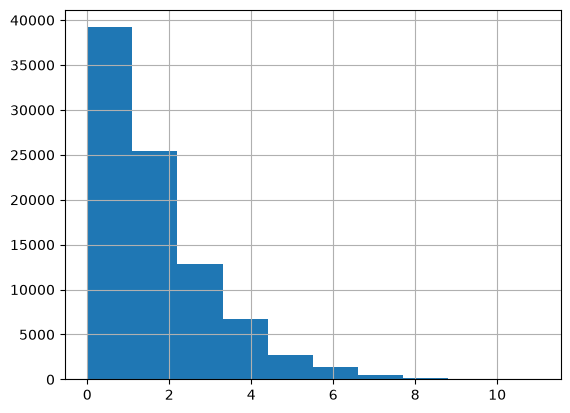

In [21]:
equations = (
    df_train["sentence"].str.findall(r"(\$\$.*?\$\$|(?<!\\)\$.*?(?<!\\)\$)").str.len()
)
print(equations.value_counts())
equations.hist()

<Axes: >

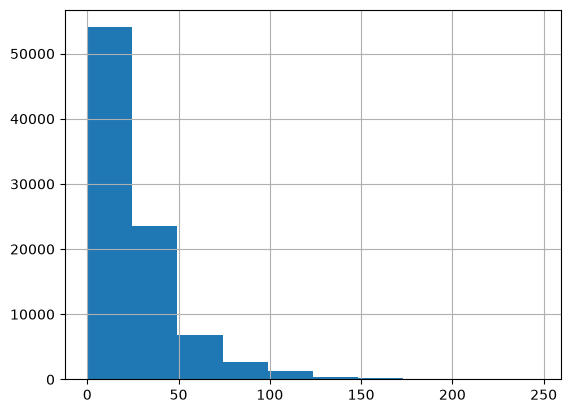

In [22]:
df_train["count_formula_symbols"].hist()

## Test Dataset Text Exploration

In [23]:
df_test.describe()

,sentence_id,is_tts,count_formula_symbols,__index_level_0__
count,2850.000000,2850.000000,2850.000000,2850.000000
mean,7449.991228,0.729123,26.176842,48790.855789
std,4478.153616,0.444491,24.055517,29254.762629
min,37.000000,0.000000,0.000000,235.000000
25%,3654.000000,0.000000,9.000000,23871.250000
50%,7138.000000,1.000000,20.000000,46909.500000
75%,11024.000000,1.000000,33.000000,72409.750000
max,16401.000000,1.000000,140.000000,102895.000000


In [24]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 2850 entries, 0 to 2849
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   spk                            2850 non-null   str    
 1   language                       2850 non-null   str    
 2   sentence_id                    2850 non-null   int64  
 3   is_tts                         2850 non-null   int64  
 4   pronunciation                  2850 non-null   str    
 5   whisper_text                   2850 non-null   str    
 6   sentence                       2850 non-null   str    
 7   formula_info                   2850 non-null   str    
 8   count_formula_symbols          2850 non-null   float64
 9   count_formula_symbols_strates  2850 non-null   str    
 10  __index_level_0__              2850 non-null   int64  
 11  sentence_normalized            2850 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 2.1 MB


In [25]:
df_test.duplicated().sum()

np.int64(0)

In [26]:
df_test.isnull().sum()

spk                              0
language                         0
sentence_id                      0
is_tts                           0
pronunciation                    0
whisper_text                     0
sentence                         0
formula_info                     0
count_formula_symbols            0
count_formula_symbols_strates    0
__index_level_0__                0
sentence_normalized              0
dtype: int64

In [27]:
df_test["language"].value_counts()

language
eng    2850
Name: count, dtype: int64

In [28]:
df_test["is_tts"].value_counts()

is_tts
1    2078
0     772
Name: count, dtype: int64

In [29]:
df_test.value_counts(subset=["spk", "is_tts"])

spk                                   is_tts
g300                                  1         697
D_voice                               1         694
Kin_24000                             1         687
b316c983-fcbc-435e-bb58-6a73b3358923  0         289
70610f1b-ab5d-414d-9bfe-7ccaf36b2408  0         117
a69e7ff9-0629-45c9-a8d9-633814503533  0          69
9875433f-1c5a-41ce-bdee-d533eeea3d44  0          55
fa1067fc-8b55-4571-95ee-eec0b99ca278  0          50
810c7f88-d103-4082-9ab5-215052e6176b  0          40
61b701a7-8eac-4920-89ac-f914a74892f7  0          39
6f955635-b2d3-4da6-bdc1-1aa6655021ff  0          29
6aba0f6b-abcf-4045-b529-f3f905474093  0          25
9849dba0-57ba-4010-8adc-f88bcff9e585  0          21
308e3ec9-b238-4d6c-ad66-c05896a00a15  0          19
1d0b98eb-b5f9-488f-97f4-bf6423f1560b  0           9
f5a5686a-35e6-40a0-925c-065b5c9ebde8  0           4
9ed0c969-c4b8-45d2-b1bf-e79eef6ca3a9  0           3
6f001cce-fead-4f85-9fcd-9c77427b5197  0           2
e8210322-9875-4c29-

count    2850.000000
mean       19.189123
std         8.408429
min         6.000000
25%        13.000000
50%        17.000000
75%        25.000000
max        58.000000
Name: sentence, dtype: float64


<Axes: >

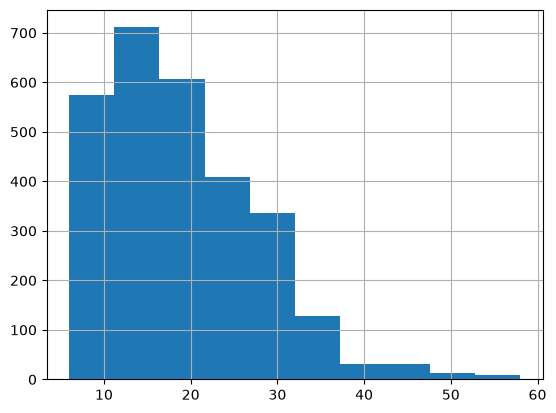

In [30]:
lens = df_test["sentence"].str.split().apply(lambda x: len(x))
print(lens.describe())
lens.hist()

In [31]:
df_test["sentence"].str.lower().str.split().explode().value_counts().head(50)

sentence
the         3998
of          1799
is          1230
a           1218
to          1173
in          1158
and         1107
we           885
that         764
for          698
be           476
by           467
are          430
with         412
as           373
on           354
=            284
an           269
it           266
this         264
which        234
let          225
will         223
then         215
if           214
at           213
from         212
can          206
have         201
has          157
not          144
each         144
\in          144
$            136
so           134
since        123
all          120
number       116
also         111
set          108
two          106
time         104
one          103
when         102
there         95
equation      94
given         93
function      91
.             90
such          89
Name: count, dtype: int64

In [32]:
print(df_test["sentence_id"].nunique())
df_test["sentence_id"].value_counts()

428


sentence_id
1118     10
3310     10
4184     10
5577     10
6613     10
         ..
6316      1
7804      1
11048     1
11832     1
13700     1
Name: count, Length: 428, dtype: int64

sentence
1    1084
2     839
3     507
4     180
0     117
5      71
6      37
7      11
9       4
Name: count, dtype: int64


<Axes: >

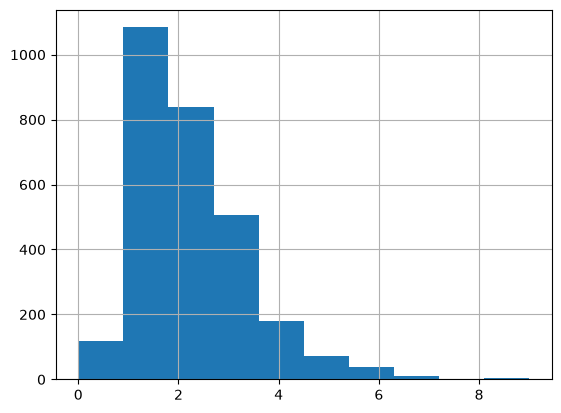

In [33]:
equations = (
    df_test["sentence"].str.findall(r"(\$\$.*?\$\$|(?<!\\)\$.*?(?<!\\)\$)").str.len()
)
print(equations.value_counts())
equations.hist()

<Axes: >

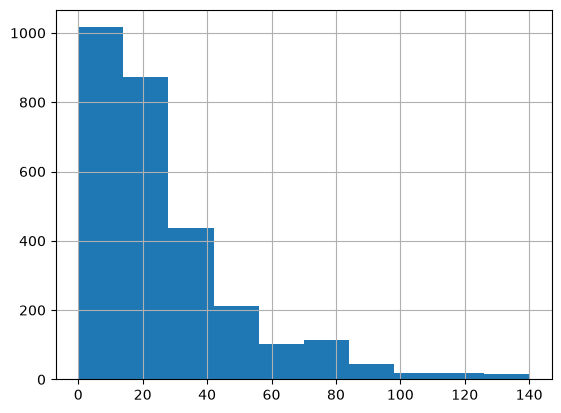

In [34]:
df_test["count_formula_symbols"].hist()